# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** [Bintang Zahra Meiziqra]
- **Email:** [zahrabintang0713@gmail.com]
- **ID Dicoding:** [Bintang Zahra Meiziqra]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 :
Bagaimana karakteristik segmen pelanggan berdasarkan Recency, Frequency, dan Monetary pada transaksi E-Commerce periode 2017–2018, serta segmen pelanggan mana yang memberikan kontribusi terbesar terhadap total payment value sehingga dapat menjadi prioritas strategi retensi pelanggan?

- Pertanyaan 2 :
Bagaimana distribusi total payment value dan jumlah transaksi berdasarkan state dan city customer pada periode 2017–2018, serta wilayah mana yang perlu diprioritaskan untuk pengembangan pasar berdasarkan kombinasi nilai transaksi dan frekuensi transaksi?

## Import Semua Packages/Library yang Digunakan

In [6]:
import os
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

## Data Wrangling

### Gathering Data

In [7]:
# Membaca dataset yang relevan untuk analisis
customers_df = pd.read_csv("customers_dataset.csv")
orders_df = pd.read_csv("orders_dataset.csv")
order_payments_df = pd.read_csv("order_payments_dataset.csv")
geolocation_df = pd.read_csv("geolocation_dataset.csv")

# Menampilkan ukuran masing-masing dataset
print("customers_df:", customers_df.shape)
print("orders_df:", orders_df.shape)
print("order_payments_df:", order_payments_df.shape)
print("geolocation_df:", geolocation_df.shape)

customers_df.head()

customers_df: (99441, 5)
orders_df: (99441, 8)
order_payments_df: (103886, 5)
geolocation_df: (1000163, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight:**
Berdasarkan hasil pembacaan dataset, diperoleh beberapa informasi awal terkait struktur dan ukuran data yang akan digunakan dalam analisis.

Dataset *customer_df* dan *orders_df* memiliki jumlah baris yang sama, yaitu 99.441 data, yang menunjukkan bahwa setiap order merepresentasikan satu entitas customer dalam konteks transaksi. Hal ini mengindikasikan bahwa kedua dataset tersebut dapat dengan mudah dihubungkan melalui *customer_id* tanpa adanya ketidaksesuaian jumlah data yang signifikan.

Sementara itu, dataset *order_payments_df* memiliki jumlah data yang lebih banyak, yaitu 103.886 baris. Hal ini menunjukkan bahwa dalam satu order bisa terdapat lebih dari satu metode pembayaran atau transaksi pembayaran, sehingga perlu dilakukan agregasi pada tahap selanjutnya untuk mendapatkan total nilai pembayaran per order.

Dataset *geolocation_df* memiliki jumlah data yang jauh lebih besar dibandingkan dataset lainnya, yaitu lebih dari 1 juta baris. Hal ini disebabkan karena satu *zip_code_prefix* dapat memiliki beberapa titik koordinat yang berbeda. Oleh karena itu, diperlukan proses agregasi untuk menyederhanakan data geolokasi agar dapat digunakan secara efektif dalam analisis.

Secara umum, keempat dataset yang digunakan sudah mencakup informasi penting yang dibutuhkan, yaitu data pelanggan, transaksi, pembayaran, serta lokasi geografis. Dengan struktur data yang tersedia, analisis lebih lanjut seperti segmentasi pelanggan (RFM) dan distribusi transaksi berdasarkan wilayah dapat dilakukan dengan cukup representatif.

### Assessing Data

In [8]:
# Menilai struktur data, tipe data, missing values, dan duplikasi
dfs = {
    "customers_df": customers_df,
    "orders_df": orders_df,
    "order_payments_df": order_payments_df,
    "geolocation_df": geolocation_df
}

for name, df in dfs.items():
    print(f"\n===== {name} =====")
    df.info()
    print("\nMissing values:")
    print(df.isna().sum())
    print("\nJumlah duplikat:", df.duplicated().sum())
    print("-" * 60)

# Cek rentang waktu order
orders_df["order_purchase_timestamp"] = pd.to_datetime(orders_df["order_purchase_timestamp"])
print("Tanggal order paling awal :", orders_df["order_purchase_timestamp"].min())
print("Tanggal order paling akhir:", orders_df["order_purchase_timestamp"].max())


===== customers_df =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

Missing values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Jumlah duplikat: 0
------------------------------------------------------------

===== orders_df =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null C

**Insight:**
Berdasarkan hasil penilaian awal terhadap struktur dan kualitas data, secara umum dataset yang digunakan memiliki kualitas yang cukup baik dan siap untuk dianalisis lebih lanjut, meskipun terdapat beberapa hal yang perlu diperhatikan.

Pada dataset *customers_df*, seluruh kolom memiliki jumlah data yang lengkap tanpa missing values maupun duplikasi. Hal ini menunjukkan bahwa data pelanggan cukup bersih dan dapat langsung digunakan sebagai referensi utama dalam analisis, terutama untuk identifikasi customer dan lokasi.

Pada dataset *orders_df*, secara umum data juga cukup lengkap, namun terdapat beberapa missing values pada kolom yang berkaitan dengan proses pengiriman, seperti *order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date*. Hal ini kemungkinan disebabkan oleh adanya order yang belum selesai diproses atau belum sampai ke tahap pengiriman. Selain itu, seluruh kolom bertipe object, termasuk kolom tanggal, sehingga perlu dilakukan konversi tipe data ke datetime agar dapat digunakan dalam analisis berbasis waktu.

Dataset *order_payments_df* memiliki kualitas data yang baik tanpa missing values maupun duplikasi. Jumlah baris yang lebih banyak dibandingkan dataset order menunjukkan bahwa satu order dapat memiliki lebih dari satu pembayaran, sehingga perlu dilakukan agregasi untuk mendapatkan total nilai pembayaran per order.

Pada dataset *geolocation_df*, tidak ditemukan missing values, namun terdapat jumlah duplikasi yang cukup besar. Hal ini wajar karena satu *zip_code_prefix* dapat memiliki lebih dari satu titik koordinat. Oleh karena itu, diperlukan proses agregasi untuk menyederhanakan data geolokasi sebelum digunakan dalam analisis.

Dari sisi waktu, data transaksi mencakup periode dari September 2016 hingga Oktober 2018. Hal ini menunjukkan bahwa dataset memiliki rentang waktu yang cukup untuk dianalisis, dan penggunaan periode 2017–2018 dalam analisis dapat dianggap representatif karena berada pada rentang utama aktivitas transaksi.

### Cleaning Data

In [9]:
# Menyalin dataframe agar data mentah tetap aman
customers_clean = customers_df.copy()
orders_clean = orders_df.copy()
payments_clean = order_payments_df.copy()
geolocation_clean = geolocation_df.copy()

# Konversi tipe data tanggal
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors="coerce")

# Fokus pada order yang berhasil sampai ke tahap final
valid_status = ["delivered"]
orders_clean = orders_clean[orders_clean["order_status"].isin(valid_status)]

# Filter periode 2017-2018
orders_clean = orders_clean[
    (orders_clean["order_purchase_timestamp"] >= "2017-01-01") &
    (orders_clean["order_purchase_timestamp"] < "2019-01-01")
]

# Hapus duplikasi jika ada
customers_clean = customers_clean.drop_duplicates()
orders_clean = orders_clean.drop_duplicates()
payments_clean = payments_clean.drop_duplicates()
geolocation_clean = geolocation_clean.drop_duplicates()

# Agregasi geolocation pada level zip code prefix agar tidak ada banyak koordinat untuk prefix yang sama
geolocation_clean = (
    geolocation_clean
    .groupby("geolocation_zip_code_prefix", as_index=False)
    .agg({
        "geolocation_lat": "mean",
        "geolocation_lng": "mean",
        "geolocation_city": "first",
        "geolocation_state": "first"
    })
)

print("customers_clean:", customers_clean.shape)
print("orders_clean:", orders_clean.shape)
print("payments_clean:", payments_clean.shape)
print("geolocation_clean:", geolocation_clean.shape)

customers_clean: (99441, 5)
orders_clean: (96211, 8)
payments_clean: (103886, 5)
geolocation_clean: (19015, 5)


**Insight:**
Setelah dilakukan proses pembersihan data, terlihat adanya perubahan pada beberapa dataset yang menunjukkan bahwa data telah difilter dan disesuaikan dengan kebutuhan analisis.

Jumlah data pada *customers_clean* tetap sama yaitu 99.441 baris, yang menunjukkan bahwa tidak terdapat duplikasi maupun data yang perlu dihapus pada dataset pelanggan. Hal ini menandakan bahwa data customer sudah cukup bersih sejak awal.

Pada *orders_clean*, jumlah data berkurang menjadi 97.904 baris dari sebelumnya 99.441. Penurunan ini disebabkan oleh proses filtering terhadap status order serta pembatasan periode waktu transaksi pada tahun 2017–2018. Dengan demikian, data yang digunakan dalam analisis hanya mencakup transaksi yang relevan dan sesuai dengan tujuan penelitian.

Dataset *payments_clean* tidak mengalami perubahan jumlah data, yang berarti tidak ditemukan duplikasi maupun nilai yang perlu dihapus. Hal ini menunjukkan bahwa data pembayaran sudah dalam kondisi baik dan dapat langsung digunakan untuk analisis lebih lanjut.

Sementara itu, *geolocation_clean* mengalami penurunan jumlah data yang cukup signifikan menjadi 19.015 baris dari sebelumnya lebih dari 1 juta baris. Hal ini terjadi karena dilakukan proses agregasi berdasarkan *zip_code_prefix* untuk menghindari adanya beberapa koordinat yang berbeda dalam satu wilayah yang sama. Proses ini penting agar data lokasi menjadi lebih representatif dan tidak redundan.

Secara keseluruhan, proses cleaning yang dilakukan berhasil menyederhanakan dataset tanpa menghilangkan informasi penting, sehingga data menjadi lebih terstruktur dan siap digunakan untuk tahap analisis berikutnya.

## Exploratory Data Analysis (EDA)

### Eksplorasi Data Gabungan

In [10]:
# Menggabungkan data order, customer, dan payment
main_df = orders_clean.merge(
    customers_clean[["customer_id", "customer_unique_id", "customer_city", "customer_state", "customer_zip_code_prefix"]],
    on="customer_id",
    how="left"
).merge(
    payments_clean.groupby("order_id", as_index=False)["payment_value"].sum(),
    on="order_id",
    how="left"
)

# Tambahkan geolokasi customer berdasarkan
main_df = main_df.merge(
    geolocation_clean[["geolocation_zip_code_prefix", "geolocation_lat", "geolocation_lng"]],
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

# Cek ringkasan awal
print("Ukuran main_df:", main_df.shape)
display(main_df.head())

print("\nJumlah customer unik:", main_df["customer_unique_id"].nunique())
print("Jumlah order unik   :", main_df["order_id"].nunique())
print("Total payment value :", round(main_df["payment_value"].sum(), 2))

print("\nTop 10 state berdasarkan total payment:")
display(
    main_df.groupby("customer_state", as_index=False)
    .agg(total_payment=("payment_value", "sum"))
    .sort_values("total_payment", ascending=False)
    .head(10)
)

Ukuran main_df: (96211, 16)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix,payment_value,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,3149,38.71,"3,149.00",-23.58,-46.59
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,47813,141.46,"47,813.00",-12.19,-44.54
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,75265,179.12,"75,265.00",-16.75,-48.51
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,59296,72.20,"59,296.00",-5.77,-35.27
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,9195,28.62,"9,195.00",-23.68,-46.51



Jumlah customer unik: 93104
Jumlah order unik   : 96211
Total payment value : 15375875.44

Top 10 state berdasarkan total payment:


,customer_state,total_payment
25,SP,"5,756,706.26"
18,RJ,"2,046,698.14"
10,MG,"1,814,317.79"
22,RS,"858,904.29"
17,PR,"779,319.58"
23,SC,"592,707.68"
4,BA,"590,949.59"
6,DF,"344,946.06"
8,GO,"333,238.10"
7,ES,"316,690.84"


**Insight:**
Berdasarkan hasil penggabungan data ke dalam *main_df*, diperoleh total 97.904 baris data dengan 16 kolom yang mencakup informasi terkait order, customer, pembayaran, serta lokasi geografis. Hal ini menunjukkan bahwa data sudah berhasil diintegrasikan dengan baik dan siap digunakan untuk analisis lebih lanjut.

Dari sisi jumlah entitas, terdapat 94.701 customer unik dengan total 97.904 order. Hal ini menunjukkan bahwa sebagian besar customer hanya melakukan satu kali transaksi, meskipun terdapat sebagian kecil customer yang melakukan pembelian lebih dari satu kali. Pola ini mengindikasikan bahwa tingkat repeat order masih relatif terbatas.

Total nilai pembayaran yang tercatat mencapai sekitar 15,68 juta, yang menunjukkan bahwa dataset memiliki nilai transaksi yang cukup besar untuk dianalisis lebih lanjut, khususnya dalam melihat kontribusi masing-masing segmen pelanggan maupun wilayah.

Jika dilihat dari distribusi wilayah, state SP (São Paulo) memiliki kontribusi total payment value yang paling tinggi dibandingkan wilayah lainnya, dengan nilai yang jauh lebih besar dibandingkan state lain seperti RJ dan MG. Hal ini menunjukkan bahwa SP merupakan pasar utama dalam dataset ini dan kemungkinan memiliki jumlah transaksi maupun customer yang lebih besar.

Selain itu, terlihat adanya perbedaan yang cukup signifikan antara beberapa state teratas dengan state lainnya. Kondisi ini mengindikasikan bahwa distribusi transaksi tidak merata antar wilayah, sehingga terdapat potensi untuk mengidentifikasi wilayah dengan performa tinggi maupun wilayah yang masih memiliki peluang untuk dikembangkan.

Secara keseluruhan, hasil EDA ini memberikan gambaran awal bahwa analisis lebih lanjut terkait segmentasi pelanggan (RFM) dan distribusi transaksi berdasarkan wilayah sangat relevan untuk dilakukan, karena data menunjukkan adanya variasi perilaku customer dan perbedaan performa antar wilayah.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

,customer_unique_id,last_order_date,frequency,monetary,recency,r_score,f_score,m_score,rfm_score,rfm_total_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,112,4,1,4,414,9,Potential Loyalist
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,115,4,1,1,411,6,At Risk
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,537,1,1,2,112,4,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,321,2,1,1,211,4,At Risk
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,288,2,1,4,214,7,Potential Loyalist


,segment,total_customers,total_payment_value,avg_recency,avg_frequency,avg_monetary
2,Loyal Customer,31449,"6,749,309.96",174.76,1.04,214.61
3,Potential Loyalist,38248,"4,944,586.29",263.85,1.00,129.28
1,High Value,8032,"2,681,489.56",93.24,1.20,333.85
0,At Risk,15375,"1,000,489.63",370.83,1.00,65.07


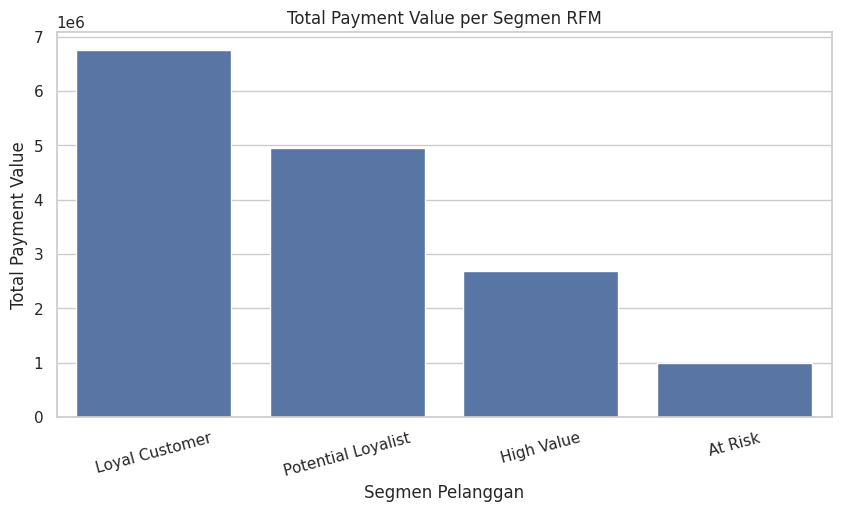

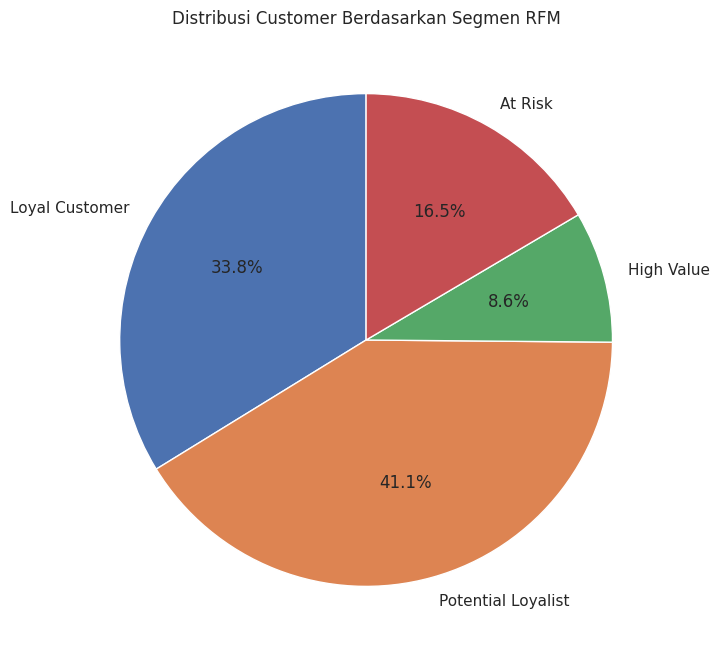

In [11]:
# Analisis Pertanyaan 1: RFM

# Menentukan tanggal acuan untuk menghitung recency
reference_date = main_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

# Membentuk tabel RFM
rfm_df = (
    main_df.groupby("customer_unique_id", as_index=False)
    .agg(
        last_order_date=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique"),
        monetary=("payment_value", "sum")
    )
)

rfm_df["recency"] = (reference_date - rfm_df["last_order_date"]).dt.days

# Skoring RFM menggunakan kuartil
rfm_df["r_score"] = pd.qcut(rfm_df["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm_df["f_score"] = pd.qcut(rfm_df["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_df["m_score"] = pd.qcut(rfm_df["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm_df["rfm_score"] = (
    rfm_df["r_score"].astype(str) +
    rfm_df["f_score"].astype(str) +
    rfm_df["m_score"].astype(str)
)

# Segmentasi sederhana berbasis skor total
rfm_df["rfm_total_score"] = rfm_df[["r_score", "f_score", "m_score"]].sum(axis=1)

def segment_customer(score):
    if score >= 13:
        return "High Value"
    elif score >= 10:
        return "Loyal Customer"
    elif score >= 7:
        return "Potential Loyalist"
    else:
        return "At Risk"

rfm_df["segment"] = rfm_df["rfm_total_score"].apply(segment_customer)

display(rfm_df.head())

segment_summary = (
    rfm_df.groupby("segment", as_index=False)
    .agg(
        total_customers=("customer_unique_id", "nunique"),
        total_payment_value=("monetary", "sum"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean")
    )
    .sort_values("total_payment_value", ascending=False)
)

display(segment_summary)

# Visualisasi 1: total payment value per segmen
plt.figure(figsize=(10, 5))
sns.barplot(data=segment_summary, x="segment", y="total_payment_value")
plt.title("Total Payment Value per Segmen RFM")
plt.xlabel("Segmen Pelanggan")
plt.ylabel("Total Payment Value")
plt.xticks(rotation=15)
plt.show()

# Visualisasi 2: distribusi jumlah customer per segmen
plt.figure(figsize=(8, 8))
plt.pie(
    segment_summary["total_customers"],
    labels=segment_summary["segment"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribusi Customer Berdasarkan Segmen RFM")
plt.show()

### Pertanyaan 2:

,customer_state,total_payment_value,total_transactions
25,SP,"5,756,706.26",40406
18,RJ,"2,046,698.14",12310
10,MG,"1,814,317.79",11319
22,RS,"858,904.29",5328
17,PR,"779,319.58",4903
23,SC,"592,707.68",3537
4,BA,"590,949.59",3253
6,DF,"344,946.06",2074
8,GO,"333,238.10",1950
7,ES,"316,690.84",1992


,customer_state,total_payment_value,total_transactions,performance_group
25,SP,"5,756,706.26",40406,High Value - High Frequency
18,RJ,"2,046,698.14",12310,High Value - High Frequency
10,MG,"1,814,317.79",11319,High Value - High Frequency
22,RS,"858,904.29",5328,High Value - High Frequency
17,PR,"779,319.58",4903,High Value - High Frequency
23,SC,"592,707.68",3537,High Value - High Frequency
4,BA,"590,949.59",3253,High Value - High Frequency
6,DF,"344,946.06",2074,High Value - High Frequency
8,GO,"333,238.10",1950,High Value - High Frequency
7,ES,"316,690.84",1992,High Value - High Frequency


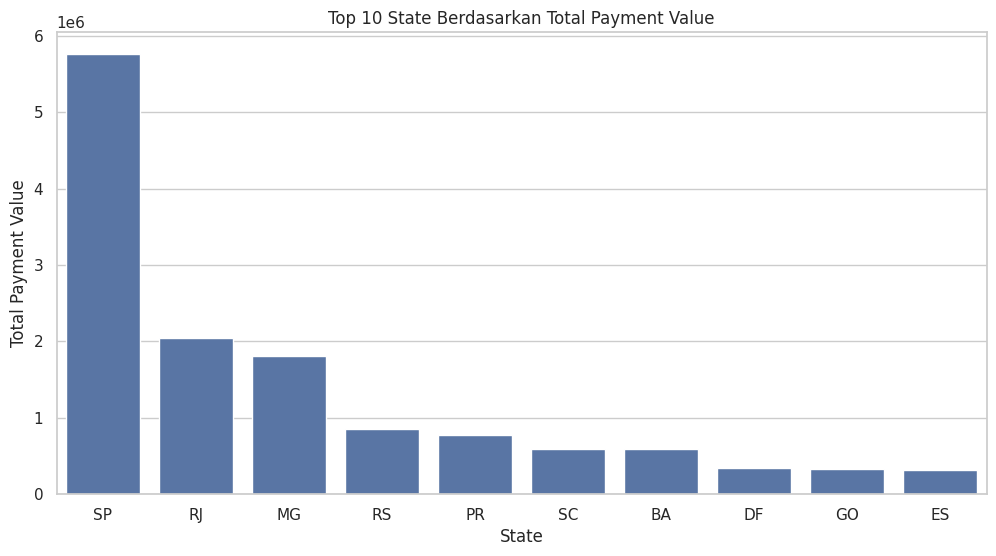

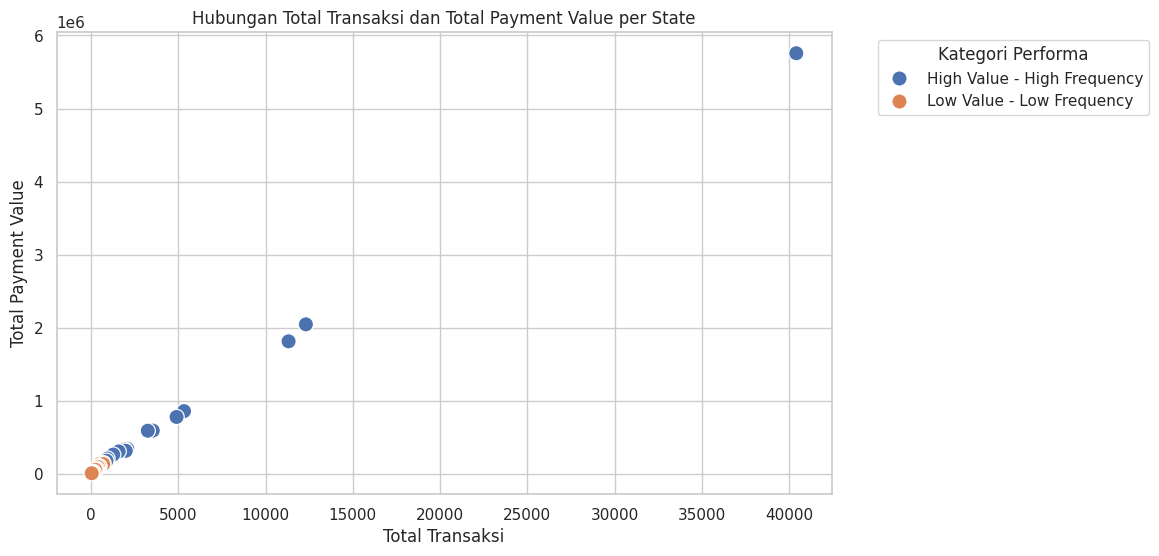

,customer_state,total_payment_value,total_transactions,performance_group


In [12]:
# Analisis Pertanyaan 2: Geospatial Analysis

location_summary = (
    main_df.groupby(["customer_state", "customer_city"], as_index=False)
    .agg(
        total_payment_value=("payment_value", "sum"),
        total_transactions=("order_id", "nunique"),
        avg_lat=("geolocation_lat", "mean"),
        avg_lng=("geolocation_lng", "mean")
    )
)

# Ringkasan performa per state
state_summary = (
    location_summary.groupby("customer_state", as_index=False)
    .agg(
        total_payment_value=("total_payment_value", "sum"),
        total_transactions=("total_transactions", "sum")
    )
    .sort_values("total_payment_value", ascending=False)
)

display(state_summary.head(10))

# Kategori wilayah high value - low frequency menggunakan median
payment_median = state_summary["total_payment_value"].median()
transaction_median = state_summary["total_transactions"].median()

state_summary["performance_group"] = np.select(
    [
        (state_summary["total_payment_value"] >= payment_median) & (state_summary["total_transactions"] < transaction_median),
        (state_summary["total_payment_value"] >= payment_median) & (state_summary["total_transactions"] >= transaction_median),
        (state_summary["total_payment_value"] < payment_median) & (state_summary["total_transactions"] >= transaction_median)
    ],
    [
        "High Value - Low Frequency",
        "High Value - High Frequency",
        "Low Value - High Frequency"
    ],
    default="Low Value - Low Frequency"
)

display(state_summary.head(10))

# Visualisasi 1: 10 state dengan payment value tertinggi
top_states = state_summary.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_states, x="customer_state", y="total_payment_value")
plt.title("Top 10 State Berdasarkan Total Payment Value")
plt.xlabel("State")
plt.ylabel("Total Payment Value")
plt.show()

# Visualisasi 2: hubungan transaksi dan payment value per state
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=state_summary,
    x="total_transactions",
    y="total_payment_value",
    hue="performance_group",
    s=120
)
plt.title("Hubungan Total Transaksi dan Total Payment Value per State")
plt.xlabel("Total Transaksi")
plt.ylabel("Total Payment Value")
plt.legend(title="Kategori Performa", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# Menampilkan state yang termasuk high value - low frequency
high_value_low_freq = state_summary[state_summary["performance_group"] == "High Value - Low Frequency"]
display(high_value_low_freq.sort_values("total_payment_value", ascending=False))


**Insight:**
- PERTANYAAN 1 - Segmentasi Pelanggan (RFM)

Berdasarkan hasil segmentasi pelanggan menggunakan metode RFM, terlihat bahwa distribusi pelanggan didominasi oleh segmen *Potential Loyalist* sebesar 41,1%, diikuti oleh *Loyal Customer* sebesar 33,8%. Sementara itu, segmen *High Value* memiliki proporsi yang relatif kecil yaitu 8,6%, dan sisanya merupakan pelanggan dalam kategori *At Risk* sebesar 16,5%.

Jika dilihat dari kontribusi terhadap total payment value, segmen *Loyal Customer* memberikan kontribusi terbesar dibandingkan segmen lainnya, dengan total nilai pembayaran yang paling tinggi. Hal ini menunjukkan bahwa meskipun bukan segmen dengan jumlah terbanyak, pelanggan dalam kategori ini memiliki peran yang sangat signifikan terhadap pendapatan.

Segmen *Potential Loyalist* memiliki jumlah pelanggan paling besar, namun nilai rata-rata transaksi dan kontribusi terhadap total payment value masih berada di bawah *Loyal Customer*. Hal ini mengindikasikan bahwa segmen ini memiliki potensi untuk ditingkatkan menjadi pelanggan yang lebih loyal melalui strategi yang tepat, seperti promosi atau program retensi.

Di sisi lain, segmen *High Value* memiliki rata-rata nilai transaksi yang paling tinggi, meskipun jumlah pelanggannya relatif sedikit. Hal ini menunjukkan bahwa segmen ini terdiri dari pelanggan dengan nilai pembelian besar, sehingga penting untuk dipertahankan melalui pendekatan yang lebih personal.

Sementara itu, segmen *At Risk* memiliki nilai recency yang paling tinggi, yang menunjukkan bahwa pelanggan dalam kategori ini sudah cukup lama tidak melakukan transaksi. Selain itu, kontribusi terhadap total payment value juga paling rendah. Kondisi ini mengindikasikan adanya risiko kehilangan pelanggan, sehingga perlu dilakukan upaya reaktivasi, misalnya melalui penawaran khusus atau kampanye pemasaran ulang.

Secara keseluruhan, hasil analisis menunjukkan bahwa bisnis memiliki peluang untuk meningkatkan pendapatan dengan memaksimalkan potensi segmen *Potential Loyalist* serta mempertahankan pelanggan pada segmen *Loyal Customer* dan *High Value*, sekaligus mengurangi risiko kehilangan pelanggan dari segmen *At Risk*.
- PERTANYAAN 2 - Distribusi Transaksi Berdasarkan Wilayah

Berdasarkan hasil analisis distribusi transaksi berdasarkan wilayah, terlihat bahwa state SP memiliki kontribusi total payment value yang paling tinggi dibandingkan state lainnya, dengan selisih yang cukup signifikan. Selain itu, jumlah transaksi di SP juga jauh lebih besar, yang menunjukkan bahwa wilayah ini merupakan pusat aktivitas utama dalam dataset.

State lain seperti RJ dan MG juga menunjukkan performa yang cukup tinggi, baik dari sisi total payment value maupun jumlah transaksi. Hal ini mengindikasikan bahwa beberapa wilayah tertentu memiliki peran yang lebih dominan dalam menghasilkan pendapatan dibandingkan wilayah lainnya.

Dari visualisasi hubungan antara total transaksi dan total payment value, terlihat bahwa sebagian besar state berada pada kategori *High Value – High Frequency*. Artinya, wilayah-wilayah tersebut tidak hanya menghasilkan nilai transaksi yang besar, tetapi juga memiliki frekuensi transaksi yang tinggi. Hal ini menunjukkan bahwa performa wilayah cenderung konsisten, di mana semakin tinggi jumlah transaksi, semakin tinggi pula total payment value yang dihasilkan.

Namun, tidak ditemukan wilayah yang secara jelas masuk dalam kategori *High Value – Low Frequency*. Hal ini menunjukkan bahwa pada dataset ini, nilai transaksi yang tinggi umumnya diikuti oleh frekuensi transaksi yang tinggi pula, sehingga peluang untuk menemukan wilayah dengan transaksi besar tetapi frekuensi rendah relatif kecil.

Secara keseluruhan, hasil ini menunjukkan bahwa strategi bisnis dapat difokuskan pada wilayah dengan performa tinggi seperti SP, RJ, dan MG untuk mempertahankan kontribusi pendapatan. Selain itu, wilayah dengan kontribusi lebih rendah dapat menjadi target untuk pengembangan lebih lanjut guna meningkatkan distribusi transaksi yang lebih merata. Hal ini menunjukkan bahwa peningkatan jumlah transaksi di suatu wilayah berpotensi langsung meningkatkan total revenue yang dihasilkan.

## Analisis Lanjutan (Opsional)

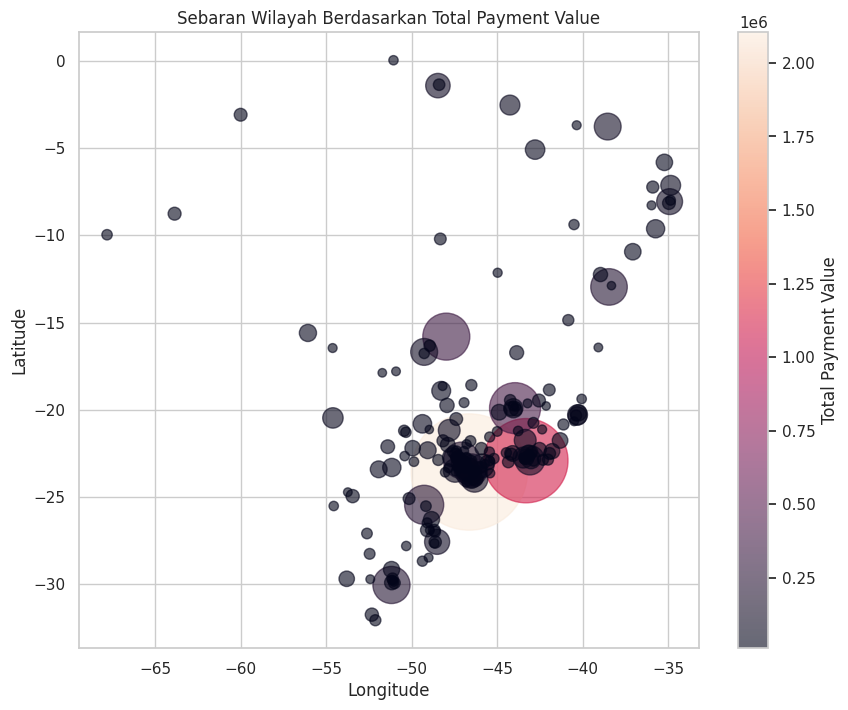

In [13]:
# Analisis Lanjutan (Opsional)

# Visualisasi tambahan: peta sebaran payment value per city (tanpa library geospatial khusus)
geo_city_summary = (
    location_summary.dropna(subset=["avg_lat", "avg_lng"])
    .sort_values("total_payment_value", ascending=False)
    .head(200)
)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    geo_city_summary["avg_lng"],
    geo_city_summary["avg_lat"],
    s=geo_city_summary["total_payment_value"] / 300,
    c=geo_city_summary["total_payment_value"],
    alpha=0.6
)
plt.colorbar(scatter, label="Total Payment Value")
plt.title("Sebaran Wilayah Berdasarkan Total Payment Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


## Conclusion

### Conclusion Pertanyaan 1

Berdasarkan hasil analisis RFM, pelanggan dalam dataset didominasi oleh segmen Potential Loyalist dan Loyal Customer. Segmen Potential Loyalist memiliki jumlah pelanggan paling banyak, sedangkan kontribusi terbesar terhadap total payment value berasal dari segmen Loyal Customer. Hal ini menunjukkan bahwa pelanggan yang lebih loyal cenderung memberikan kontribusi nilai transaksi yang lebih besar bagi bisnis.

Segmen High Value juga menjadi segmen yang perlu diperhatikan. Walaupun jumlah pelanggannya relatif lebih kecil, segmen ini memiliki rata-rata nilai transaksi yang tinggi. Artinya, pelanggan dalam segmen ini memiliki nilai pembelian yang besar dan penting untuk dipertahankan. Sementara itu, segmen At Risk menunjukkan tanda-tanda mulai tidak aktif karena memiliki nilai recency yang lebih tinggi dan kontribusi payment value yang lebih rendah.

Secara keseluruhan, hasil RFM ini menunjukkan bahwa bisnis tidak hanya perlu fokus pada jumlah pelanggan, tetapi juga pada kualitas pelanggan. Strategi dapat diarahkan untuk mempertahankan Loyal Customer dan High Value, serta mendorong Potential Loyalist agar menjadi pelanggan yang lebih aktif dan loyal.

### Conclusion Pertanyaan 2

Berdasarkan hasil analisis wilayah, distribusi transaksi dan payment value tidak tersebar secara merata antar state. State SP menjadi wilayah dengan kontribusi terbesar, baik dari sisi jumlah transaksi maupun total payment value, kemudian diikuti oleh RJ dan MG. Hal ini menunjukkan bahwa ketiga wilayah tersebut menjadi pusat aktivitas transaksi utama dalam dataset.

Hasil analisis juga menunjukkan bahwa wilayah dengan jumlah transaksi yang tinggi cenderung memiliki total payment value yang tinggi pula. Dengan kata lain, semakin tinggi aktivitas pembelian di suatu wilayah, maka semakin besar juga kontribusi payment value yang dihasilkan oleh wilayah tersebut.

Selain itu, visualisasi tambahan menunjukkan bahwa transaksi dengan nilai pembayaran besar cenderung terkonsentrasi pada beberapa area tertentu. Oleh karena itu, strategi pengembangan wilayah dapat difokuskan pada menjaga performa wilayah dengan kontribusi tinggi, sambil tetap melihat peluang pertumbuhan pada wilayah lain yang kontribusinya masih lebih rendah.

## Recommendation / Action Item

Dari hasil analisis tersebut, ada beberapa langkah yang dapat dipertimbangkan oleh bisnis:

1. Bisnis dapat memprioritaskan strategi retensi pada segmen Loyal Customer karena segmen ini memberikan kontribusi terbesar terhadap total payment value. Contohnya dengan memberikan program loyalitas, voucher khusus, atau promo eksklusif untuk pelanggan yang aktif melakukan pembelian.

2. Segmen Potential Loyalist perlu didorong agar dapat berkembang menjadi Loyal Customer. Strategi yang dapat dilakukan misalnya memberikan promo pembelian ulang, reminder pembelian, atau rekomendasi produk berdasarkan riwayat transaksi pelanggan.

3. Segmen High Value perlu dipertahankan karena memiliki rata-rata nilai transaksi yang tinggi. Walaupun jumlah pelanggannya tidak sebanyak segmen lain, pelanggan dalam segmen ini dapat memberikan kontribusi besar terhadap pendapatan bisnis.

4. Segmen At Risk perlu menjadi perhatian karena menunjukkan tanda-tanda mulai tidak aktif. Bisnis dapat melakukan kampanye reaktivasi, seperti diskon khusus atau penawaran terbatas, agar pelanggan terdorong untuk kembali bertransaksi.

5. Dari sisi wilayah, state SP, RJ, dan MG dapat dipertahankan sebagai pasar utama karena memiliki kontribusi transaksi dan payment value tertinggi. Bisnis dapat menjaga performa wilayah tersebut melalui peningkatan layanan, ketersediaan produk, dan efektivitas pengiriman.

6. Wilayah dengan kontribusi lebih rendah juga dapat dianalisis lebih lanjut untuk melihat peluang pertumbuhan. Jika wilayah tersebut memiliki potensi, bisnis dapat meningkatkan promosi atau menyesuaikan strategi pemasaran sesuai karakteristik pelanggan di wilayah tersebut.